In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import torch
from torch import nn
from scipy.stats import ttest_rel
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.interpolate import griddata
import matplotlib.patheffects as pe
from matplotlib.ticker import MultipleLocator

size_text =24
plt.rcParams.update({
    'font.family': 'serif',
    'text.usetex': False,  # Evita usar LaTeX
    'axes.titlesize': size_text,
    'xtick.labelsize': size_text,
    'ytick.labelsize': size_text,
    'legend.fontsize': size_text,
    'ytick.major.size': 2,
    'xtick.major.size': 2,
})

p = 8
q = 6

# dataset

In [ ]:
df = pd.read_csv("Case_3.csv")
df.head()

,h,k,p,d,VF
0,-50.0,-50.0,0.1,30,0.445178
1,-50.0,-49.5,0.1,30,0.449613
2,-50.0,-49.0,0.1,30,0.453985
3,-50.0,-48.5,0.1,30,0.458291
4,-50.0,-48.0,0.1,30,0.462532


In [ ]:
X = df.drop("VF", axis = 1)
y = df[["VF"]]

# Train - Test Set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data scaling

In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()



X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_test_scaled = scaler_y.transform(y_test).ravel()

# Visualization of actual data

In [ ]:
df_d30 = df[np.isclose(df['d'], 30, atol=0.1)]
# Extraer h, k y VF
h = df_d30['h'].values
k = df_d30['k'].values
vf = df_d30['VF'].values

# Crear grilla regular para h y k
grid_h, grid_k = np.meshgrid(
    np.linspace(h.min(), h.max(), 200),
    np.linspace(k.min(), k.max(), 200)
)

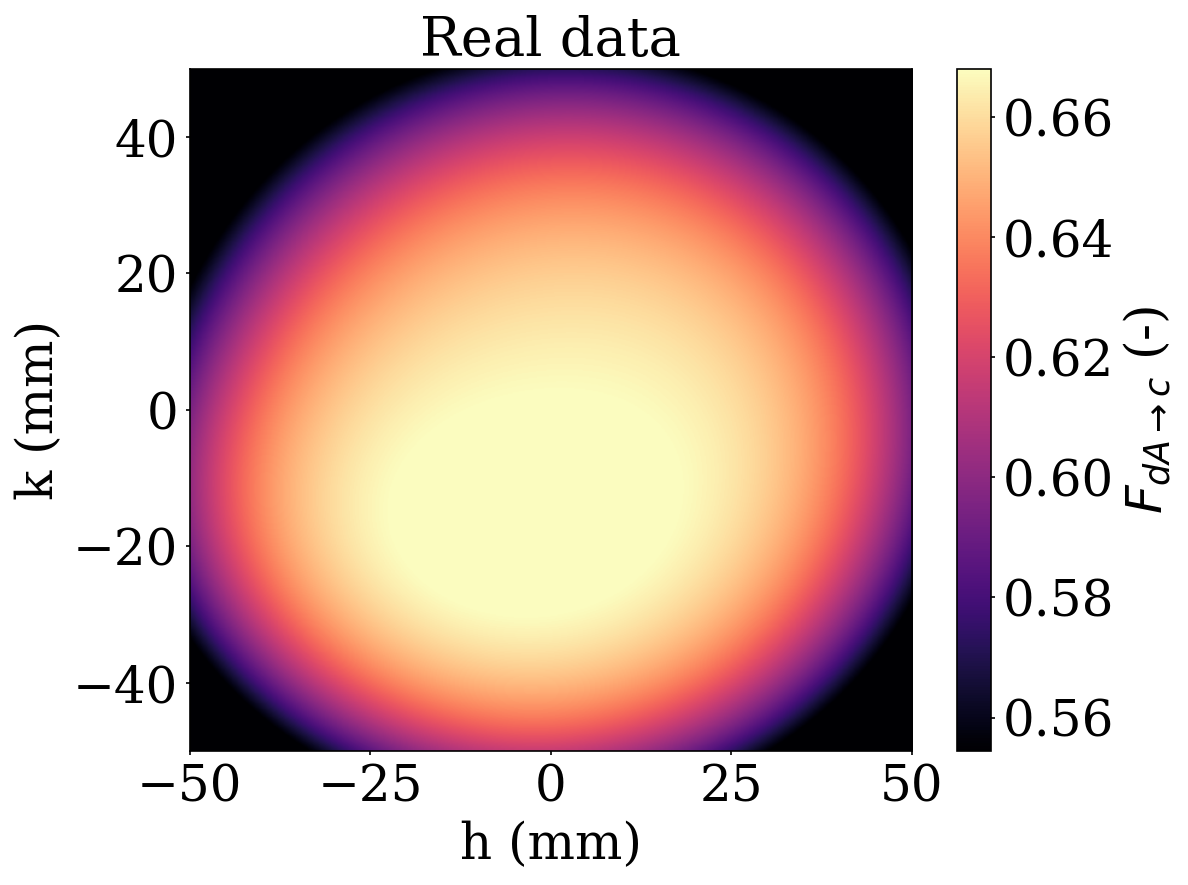

In [ ]:
size_text = 24


r = np.sqrt(h**2 + k**2)


grid_h, grid_k = np.meshgrid(
    np.linspace(h.min(), h.max(), 600),
    np.linspace(k.min(), k.max(), 600)
)
grid_vf = griddata((h, k), vf, (grid_h, grid_k), method='cubic')

norm = Normalize(vmin=np.percentile(grid_vf[~np.isnan(grid_vf)], 10),
                 vmax=np.percentile(grid_vf[~np.isnan(grid_vf)], 90))


p, q = 8, 6


fig, ax = plt.subplots(1, 1, figsize=(p, q), dpi=150)

img = ax.imshow(grid_vf, extent=(h.min(), h.max(), k.min(), k.max()),
                origin='lower', aspect='auto', cmap='magma', norm=norm)

cbar = fig.colorbar(img, ax=ax)
cbar.set_label(label=r'$F_{dA\to c}$ (-)', size=size_text)


ax.set_title("Real data", fontsize= size_text + 2)
ax.set_xlabel("h (mm)", fontsize= size_text)
ax.set_ylabel("k (mm)", fontsize= size_text)

#ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)


plt.tight_layout()
plt.savefig("Heatmap_mlp_datos_reales.png", dpi=400, bbox_inches='tight')
#plt.savefig("Heatmap_mlp_predictions.pdf", dpi=400, bbox_inches='tight')
#plt.savefig("Heatmap_mlp_predictions.eps", dpi=400, bbox_inches='tight')
plt.show()

# Conversion to tensors

In [ ]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled.reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled.reshape(-1, 1), dtype=torch.float32)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds  = TensorDataset(X_test_tensor, y_test_tensor)

train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
test_dl  = DataLoader(test_ds , batch_size=256, shuffle=False)

# Build the model

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


# Training of the model

In [ ]:
model = MLP()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
epochs = 300
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()


    train_losses.append(loss.item())


    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_test_tensor), y_test_tensor).item()
        val_losses.append(val_loss)

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.5f}, Test Loss: {val_loss:.5f}")


with torch.no_grad():
    y_pred_scaled = model(X_test_tensor)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.numpy())
    y_test_real = scaler_y.inverse_transform(y_test_tensor.numpy())

Epoch 50/300, Train Loss: 0.29999, Test Loss: 0.27815
Epoch 100/300, Train Loss: 0.07835, Test Loss: 0.07196
Epoch 150/300, Train Loss: 0.03424, Test Loss: 0.03062
Epoch 200/300, Train Loss: 0.01572, Test Loss: 0.01366
Epoch 250/300, Train Loss: 0.00819, Test Loss: 0.00696
Epoch 300/300, Train Loss: 0.00467, Test Loss: 0.00398


# Metrics

In [ ]:
model.eval()
with torch.no_grad():
    y_train_pred_scaled = model(X_train_tensor).numpy()
    y_test_pred_scaled = model(X_test_tensor).numpy()

# --- Paso 2: Inverso del escalamiento ---
y_train_true = scaler_y.inverse_transform(y_train_tensor.numpy())
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)

y_test_true = scaler_y.inverse_transform(y_test_tensor.numpy())
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

# --- Paso 3: Calcular métricas ---
def print_metrics(y_true, y_pred, dataset="Train"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # Error porcentual medio absoluto

    print(f"Métricas para {dataset}:")
    print(f"MSE   : {mse:.6e}")
    print(f"RMSE  : {rmse:.6e}")
    print(f"MAE   : {mae:.6e}")
    print(f"R²    : {r2:.6f}")
    print(f"MAPE  : {mape:.4f} %")



# Metrics of training

In [ ]:
print_metrics(y_train_true, y_train_pred, dataset="Train")

Métricas para Train:
MSE   : 1.105947e-05
RMSE  : 3.325578e-03
MAE   : 1.742388e-03
R²    : 0.995369
MAPE  : 0.3076 %


# Metrics of testing

In [ ]:
print_metrics(y_test_true, y_test_pred, dataset="Test")

Métricas para Test:
MSE   : 9.497657e-06
RMSE  : 3.081827e-03
MAE   : 1.686827e-03
R²    : 0.995944
MAPE  : 0.2957 %


# Learning curves

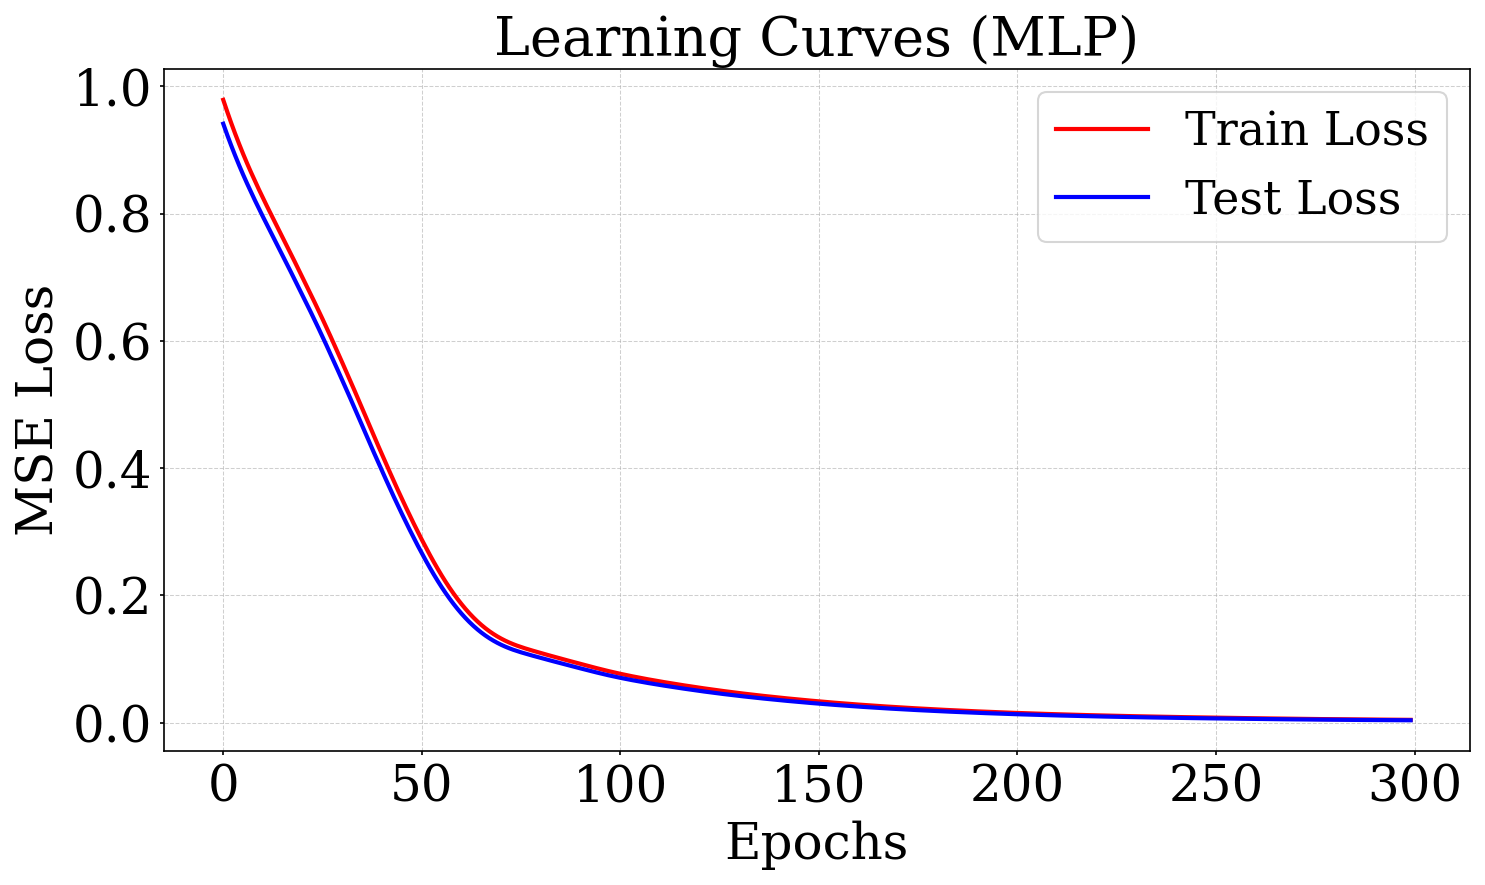

In [ ]:
size_text = 24


fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

ax.plot(train_losses, label="Train Loss", color="red", linewidth=2)
ax.plot(val_losses, label="Test Loss", color="blue", linewidth=2)


ax.set_title("Learning Curves (MLP)", fontsize=size_text + 2)
ax.set_xlabel("Epochs", fontsize=size_text)
ax.set_ylabel("MSE Loss", fontsize=size_text)


ax.legend(fontsize=size_text - 2)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)


plt.tight_layout()
#plt.savefig("learning_curve_mlp_loss.png", dpi=400, bbox_inches='tight')
plt.savefig("learning_curve_mlp_loss.pdf", dpi=400, bbox_inches='tight')
#plt.savefig("learning_curve_mlp_loss.eps", dpi=400, bbox_inches='tight')

plt.show()

# Predicted versus actual values

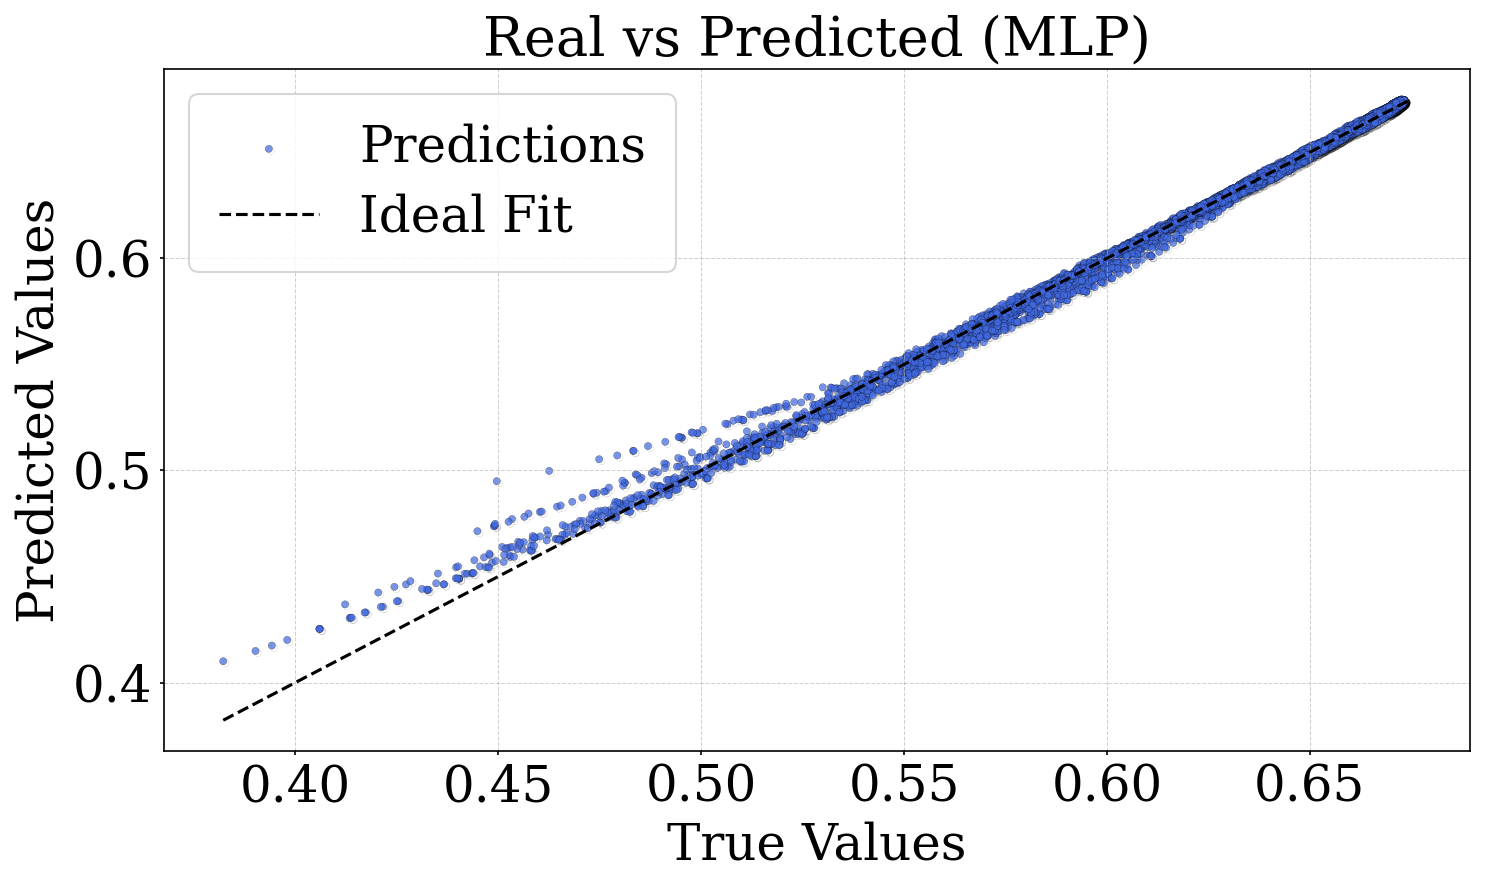

In [ ]:
size_text = 24
plt.rcParams.update({
    'font.family': 'serif',
    'text.usetex': False,
    'axes.titlesize': size_text + 2,
    'axes.labelsize': size_text,
    'xtick.labelsize': size_text,
    'ytick.labelsize': size_text,
    'legend.fontsize': size_text,
    'ytick.major.size': 2,
    'xtick.major.size': 2,
})

w, h = 10, 6


model.eval()
with torch.no_grad():
    y_pred_scaled_best = model(X_test_tensor)
    y_pred_best = scaler_y.inverse_transform(y_pred_scaled_best.cpu().numpy())
    y_test_real = scaler_y.inverse_transform(y_test_tensor.cpu().numpy())


fig, ax = plt.subplots(figsize=(w, h), dpi=150)


shadow = [pe.SimpleLineShadow(offset=(1, -1), alpha=0.25), pe.Normal()]

sc = ax.scatter(
    y_test_real, y_pred_best,
    s=12,
    alpha=0.7,
    color='royalblue',
    edgecolor='black',
    linewidth=0.15,
    label="Predictions"
)
sc.set_path_effects(shadow)

# Ideal Fit
min_val = float(min(y_test_real.min(), y_pred_best.min()))
max_val = float(max(y_test_real.max(), y_pred_best.max()))
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label="Ideal Fit")

ax.set_title("Real vs Predicted (MLP)")
ax.set_xlabel("True Values")
ax.set_ylabel("Predicted Values")

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)


# step = 0.05
# ax.xaxis.set_major_locator(MultipleLocator(step))
# ax.yaxis.set_major_locator(MultipleLocator(step))


ax.legend(
    loc="upper left",
    prop={'size': size_text},
    markerscale=1.0,
    handlelength=2.0,
    borderpad=0.6,
    labelspacing=0.4,
    frameon=True
)

plt.tight_layout()
plt.savefig("ideal_fit_case_3(1).pdf", dpi=400, bbox_inches='tight')
plt.show()

# Heatmap of mlp predictions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


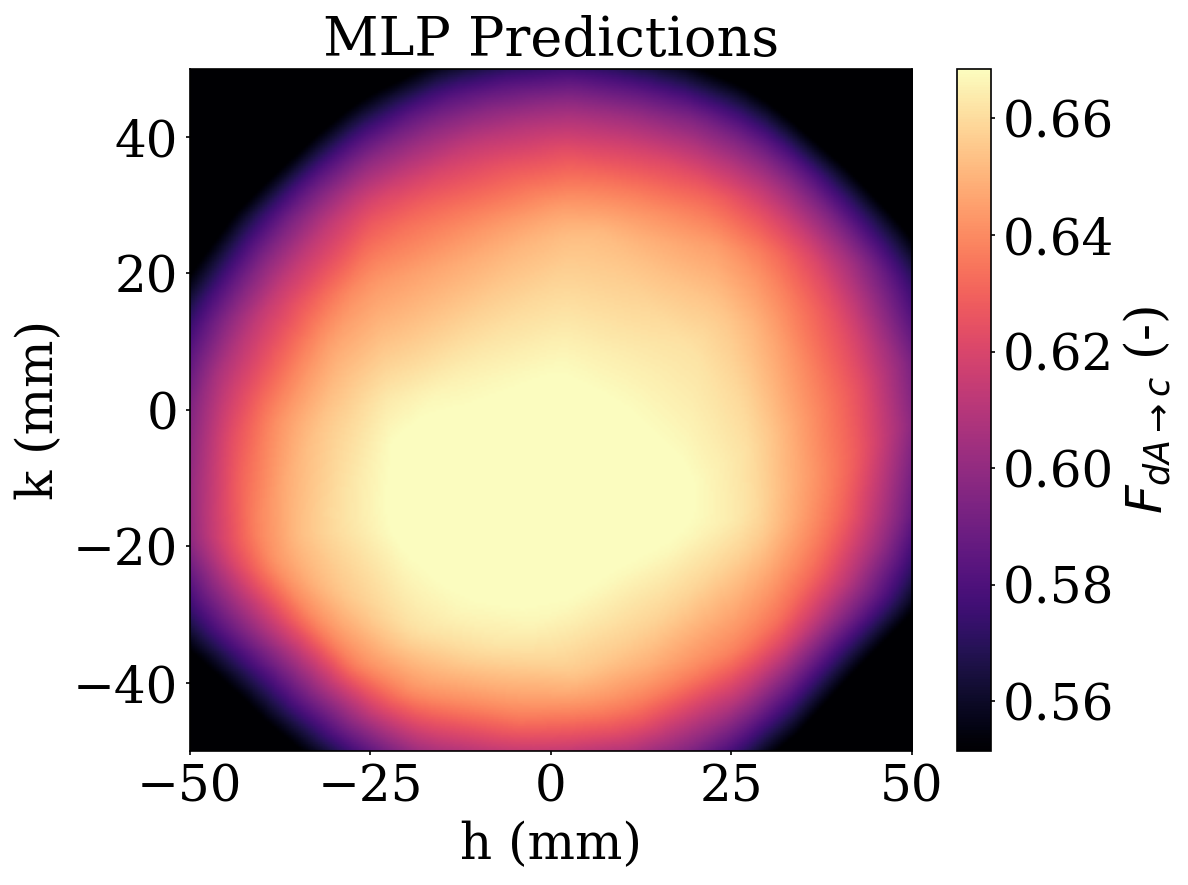

In [ ]:
size_text = 24
plt.rcParams.update({
    'font.family': 'serif',
    'text.usetex': False,
    'axes.titlesize': size_text + 2,
    'axes.labelsize': size_text,
    'xtick.labelsize': size_text,
    'ytick.labelsize': size_text,
    'legend.fontsize': size_text,
    'ytick.major.size': 2,
    'xtick.major.size': 2,
})


h_vals = np.linspace(-50, 50, 300)
k_vals = np.linspace(-50, 50, 300)
grid_h, grid_k = np.meshgrid(h_vals, k_vals)


p_fixed = 0.1
d_fixed = 30


h_flat = grid_h.ravel()
k_flat = grid_k.ravel()
p_flat = np.full_like(h_flat, p_fixed)
d_flat = np.full_like(h_flat, d_fixed)
X_grid = np.stack([h_flat, k_flat, p_flat, d_flat], axis=1)


X_grid_scaled = scaler_X.transform(X_grid)
X_tensor = torch.tensor(X_grid_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    y_scaled = model(X_tensor).numpy()
    y_grid = scaler_y.inverse_transform(y_scaled).flatten()


VF_grid = y_grid.reshape(grid_h.shape)


norm = Normalize(
    vmin=np.percentile(VF_grid[~np.isnan(VF_grid)], 10),
    vmax=np.percentile(VF_grid[~np.isnan(VF_grid)], 90)
)


p, q = 8, 6


fig, ax = plt.subplots(1, 1, figsize=(p, q), dpi=150)

img = ax.imshow(
    VF_grid,
    extent=(h_vals.min(), h_vals.max(), k_vals.min(), k_vals.max()),
    origin='lower',
    aspect='auto',
    cmap='magma',
    norm=norm
)


cbar = fig.colorbar(img, ax=ax)
cbar.set_label(label=r'$F_{dA\to c}$ (-)', size=size_text)

ax.set_title("MLP Predictions")
ax.set_xlabel("h (mm)")
ax.set_ylabel("k (mm)")

plt.tight_layout()
plt.savefig("heatmap_mlp_predicciones.png", dpi=400, bbox_inches='tight')
#plt.savefig("heatmap_vf_mlp.pdf", dpi=400, bbox_inches='tight')
#plt.savefig("heatmap_vf_mlp.eps", dpi=400, bbox_inches='tight')

plt.show()